In [ ]:
!pip install -q astroquery gala

from astroquery.gaia import Gaia
from astropy.coordinates import SkyCoord
import astropy.units as u
from gala.coordinates import GD1Koposov10

from google.colab import files

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Polygon
from scipy.spatial import cKDTree
from scipy.stats import gaussian_kde


import os
import pickle
from pathlib import Path


from tqdm import tqdm
np.random.seed(42)



In [ ]:
RA_MIN  = 120
RA_MAX  = 220

dec_lo = 0
dec_hi = 70


RA_STEP  = 10




# OUTPUT TABLE
all_tables = []









# QUERY LOOP
ra_edges = np.arange(RA_MIN, RA_MAX, RA_STEP)




# Defining a directory and a path for caching the data
DATA_DIR = Path.cwd() / "data_cache"
DATA_DIR.mkdir(parents=True, exist_ok=True)



CACHED_DATA = DATA_DIR / "Data.pkl"




if CACHED_DATA.exists():

    print(f"Loading df1 from cache: {CACHED_DATA}")
    data = pd.read_pickle(CACHED_DATA)




else:


    print(f"Cache not found. Mounting Google Drive and loading from AstroQuery \n")



    all_tables = []



    for ra_lo in tqdm(ra_edges):

        ra_hi = ra_lo + RA_STEP

        print(
            f"\n\nQuerying RA=[{ra_lo},{ra_hi}] "
            f"DEC=[{dec_lo},{dec_hi}]"
        )

        query = f"""
                SELECT
                ra,
                dec,
                pmra,
                pmdec,
                parallax,

                phot_g_mean_mag AS g,

                bp_rp,


                ruwe

            FROM gaiadr3.gaia_source

            WHERE
                ra BETWEEN {ra_lo} AND {ra_hi}
                AND dec BETWEEN {dec_lo} AND {dec_hi}

                AND phot_g_mean_mag BETWEEN 14 AND 21

                AND ruwe < 1.4

                AND parallax < 1

                AND bp_rp IS NOT NULL
            """

        #    ra_lo = ra_hi

        try:

            job = Gaia.launch_job_async(query)

            tb = job.get_results().to_pandas()

            print("\nReturned:", len(tb))

            all_tables.append(tb)



        except Exception as e:

            print("FAILED:", e)





    # MERGE RESULTS
    data = pd.concat(all_tables, ignore_index=True)
    print("\nTotal stars retrieved:", len(data))




    # Saving the DataFrame to cache as a pickle file
    print(f"Saving data to cache: {CACHED_DATA}\n")
    data.to_pickle(CACHED_DATA)



display(data.head())


Loading df1 from cache: /content/data_cache/Data.pkl


,ra,dec,pmra,pmdec,parallax,g,bp_rp,ruwe
0,126.290474,38.876883,-4.577220,-3.417785,-0.113240,18.943552,1.30085,0.939303
1,126.281833,38.943539,-5.152035,-4.303753,0.543054,19.068266,1.67898,1.050956
2,126.109676,38.954335,-4.285257,-5.030067,0.779065,19.605545,2.29744,1.014100
3,126.013587,38.993893,-0.167418,-0.812775,0.206865,18.696934,0.62438,1.034800
4,126.013505,39.006194,11.211565,-30.555221,0.769386,17.540342,1.25281,0.976063


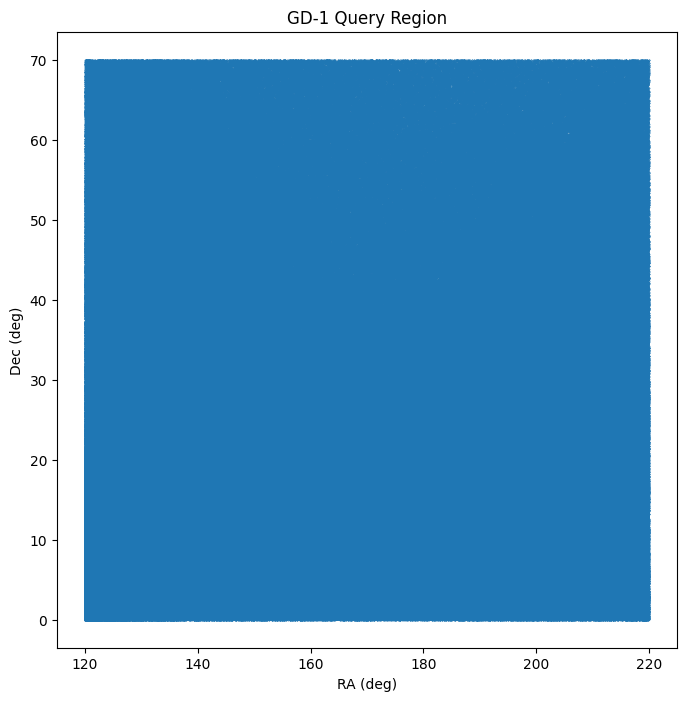

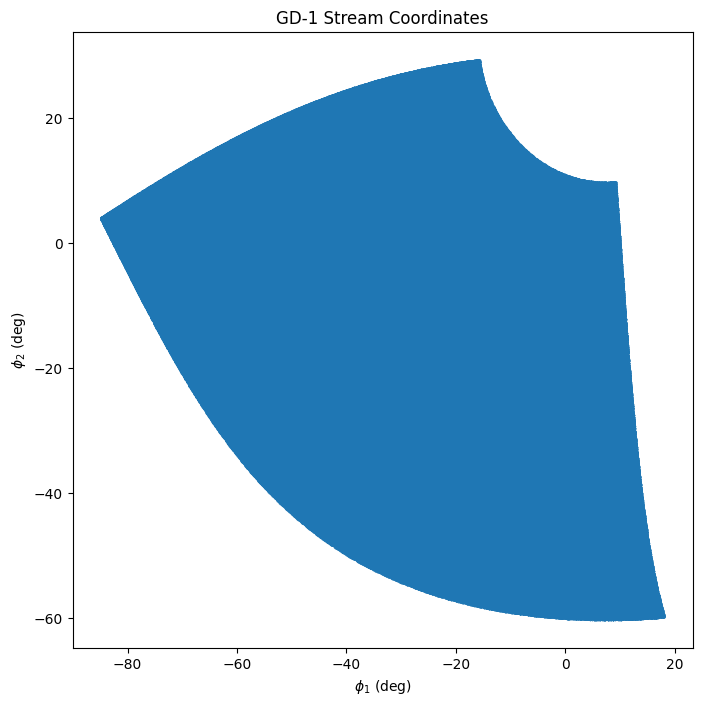

In [ ]:
df = data.sample(n=2000000)






ra = np.radians(df["ra"].values)
dec = np.radians(df["dec"].values)

# Equatorial Cartesian coordinates

x = np.cos(dec) * np.cos(ra)
y = np.cos(dec) * np.sin(ra)
z = np.sin(dec)

vec = np.vstack([x, y, z])



R = np.array([
[-0.4776303088, -0.1738432154,  0.8611897727],
[ 0.5108445890, -0.8524449229,  0.1112450420],
[ 0.7147776536,  0.4930681392,  0.4959603976]
])

rot = R @ vec

x2 = rot[0]
y2 = rot[1]
z2 = rot[2]

phi1 = np.degrees(np.arctan2(y2, x2))
phi2 = np.degrees(np.arcsin(z2))

df["phi1"] = phi1
df["phi2"] = phi2





# PLOTTING RA DEC

plt.figure(figsize=(8,8))

plt.scatter(
    df["ra"],
    df["dec"],
    s=0.1
)

plt.xlabel("RA (deg)")
plt.ylabel("Dec (deg)")
plt.title("GD-1 Query Region")

plt.show()







# PLOTTING STREAM COORDINATES


plt.figure(figsize=(8,8))

plt.scatter(
    df["phi1"],
    df["phi2"],
    s=0.1
)

plt.xlabel(r"$\phi_1$ (deg)")
plt.ylabel(r"$\phi_2$ (deg)")
plt.title("GD-1 Stream Coordinates")

plt.show()


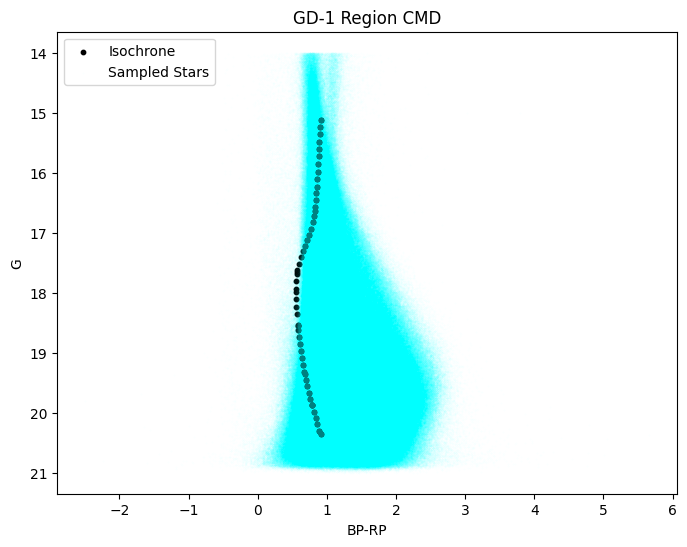

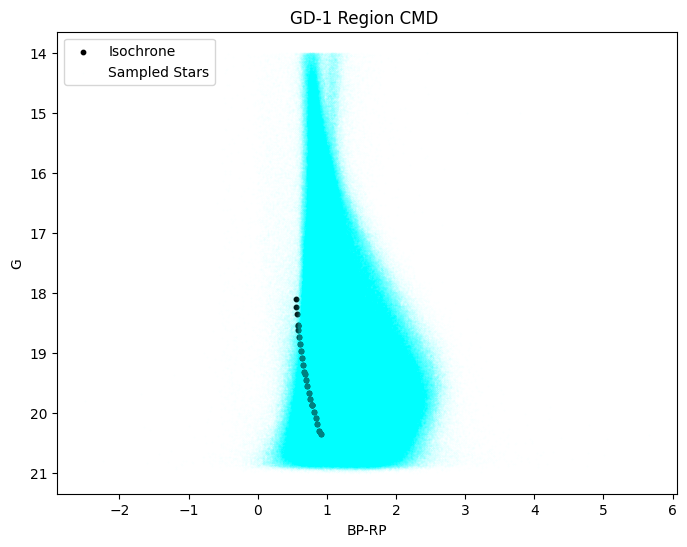

In [ ]:
# HR DIAGRAM



isochrone = {           # Apparant G_mag
    "g": [
20.362, 20.298, 20.185, 20.086, 19.989,
19.874, 19.865, 19.776, 19.667, 19.561, 19.456, 19.360, 19.313,
19.199, 19.085, 18.965, 18.855, 18.739, 18.613, 18.557, 18.533,
18.359, 18.231, 18.102, 17.986, 17.938, 17.797, 17.684, 17.658,
17.627, 17.513, 17.408, 17.308, 17.214, 17.124, 17.035, 16.940,
16.827, 16.720, 16.641, 16.563, 16.456, 16.343, 16.230, 16.101,
15.986, 15.860, 15.725, 15.606, 15.482, 15.360, 15.240, 15.122
],

    "bp_rp": [
0.909, 0.893, 0.865, 0.838, 0.814,
0.785, 0.783, 0.763, 0.741, 0.720, 0.701, 0.683, 0.675,
0.658, 0.641, 0.625, 0.612, 0.600, 0.588, 0.583, 0.580,
0.567, 0.559, 0.553, 0.550, 0.551, 0.557, 0.566, 0.569,
0.574, 0.595, 0.620, 0.651, 0.685, 0.719, 0.749, 0.777,
0.801, 0.818, 0.828, 0.834, 0.843, 0.850, 0.856, 0.863,
0.868, 0.874, 0.880, 0.886, 0.892, 0.898, 0.903, 0.909
]
}

iso = pd.DataFrame(isochrone)



plt.figure(figsize=(8,6))

plt.scatter(
    iso["bp_rp"],
    iso["g"],
    s=10,
    c='black',
    label="Isochrone"
)

plt.scatter(
    df["bp_rp"],
    df["g"],
    s=0.1,
    c='cyan',
    alpha=0.02,
    label="Sampled Stars"
)

plt.gca().invert_yaxis()

plt.xlabel("BP-RP")
plt.ylabel("G")
plt.legend(loc="upper left")
plt.title("GD-1 Region CMD")

plt.show()




# Furthur restricting to near the GD-1 Stream (i.e with Apparent G_mag greater than 18)

iso=iso[iso["g"]>18]



plt.figure(figsize=(8,6))

plt.scatter(
    iso["bp_rp"],
    iso["g"],
    s=10,
    c='black',
    label="Isochrone"
)



plt.scatter(
    df["bp_rp"],
    df["g"],
    s=0.1,
    c='cyan',
    alpha=0.02,
    label="Sampled Stars"
)

plt.gca().invert_yaxis()

plt.xlabel("BP-RP")
plt.ylabel("G")
plt.legend(loc="upper left")
plt.title("GD-1 Region CMD ")

plt.show()



No. of Stars in the Selected Cluster : 3409779


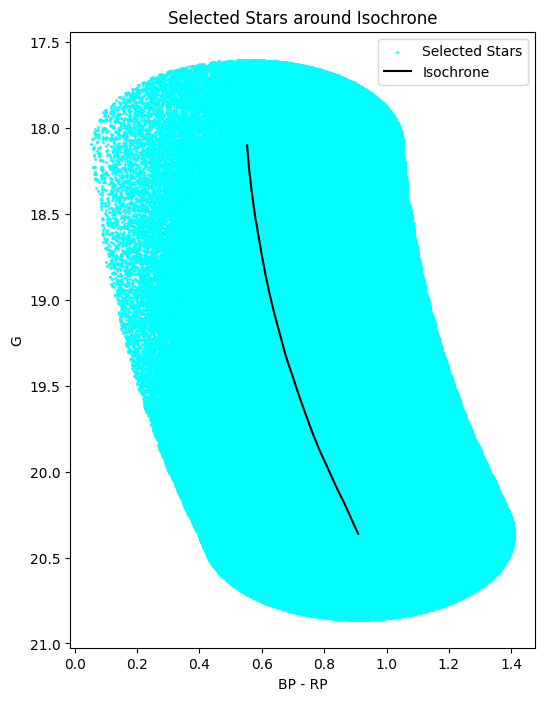

In [ ]:
tree = cKDTree ( np.column_stack([iso["bp_rp"], iso["g"]]))


dist, _ = tree.query ( np.column_stack([data["bp_rp"], data["g"]]), k=1 )


cluster = data[dist < 0.5]

print ("\nNo. of Stars in the Selected Cluster :", len(cluster))



plt.figure(figsize=(6,8))

plt.scatter(
    cluster["bp_rp"],
    cluster["g"],
    s=1,
    color="cyan",
    label="Selected Stars"
)


plt.plot(
    iso["bp_rp"],
    iso["g"],
    color="black",
    label="Isochrone"
)

plt.gca().invert_yaxis()

plt.xlabel("BP - RP")
plt.ylabel("G")
plt.title("Selected Stars around Isochrone")
plt.legend(loc="upper right")

plt.show()

/tmp/ipykernel_904/3582288857.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster["phi1"] = gd1.phi1
/tmp/ipykernel_904/3582288857.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster["phi2"] = gd1.phi2
/tmp/ipykernel_904/3582288857.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.htm

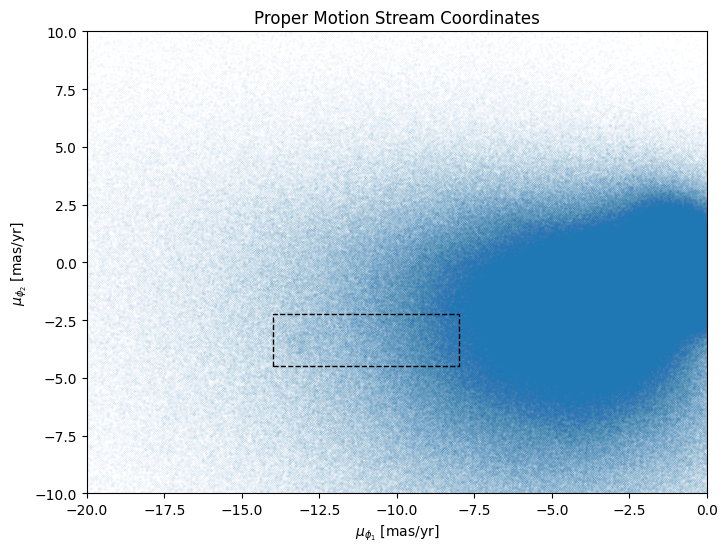

In [ ]:
ra=cluster["ra"].values
dec=cluster["dec"].values
pmra=cluster["pmra"].values
pmdec=cluster["pmdec"].values


c = SkyCoord(
    ra=ra*u.deg,
    dec=dec*u.deg,
    pm_ra_cosdec=pmra*u.mas/u.yr,
    pm_dec=pmdec*u.mas/u.yr
)

gd1 = c.transform_to(GD1Koposov10())

cluster["phi1"] = gd1.phi1
cluster["phi2"] = gd1.phi2

cluster["pm_phi1"] = gd1.pm_phi1_cosphi2
cluster["pm_phi2"]  = gd1.pm_phi2





# Plotting Proper Motion Stream Coordinates


plt.figure(figsize=(8,6))

plt.scatter(
    cluster["pm_phi1"],
    cluster["pm_phi2"],
    s=0.0002
)


plt.gca().add_patch(Rectangle(
        (-14, -4.5),
        6,
        2.25,
        fill=False,
        edgecolor='black',
        linestyle='--',
    )
)


plt.xlabel(r'$\mu_{\phi_1}$ [mas/yr]')
plt.ylabel(r'$\mu_{\phi_2}$ [mas/yr]')

plt.xlim(-20,0)
plt.ylim(-10,10)

plt.title("Proper Motion Stream Coordinates")

plt.show()


No. of Stars in the GD1_canditate Cluster : 82713


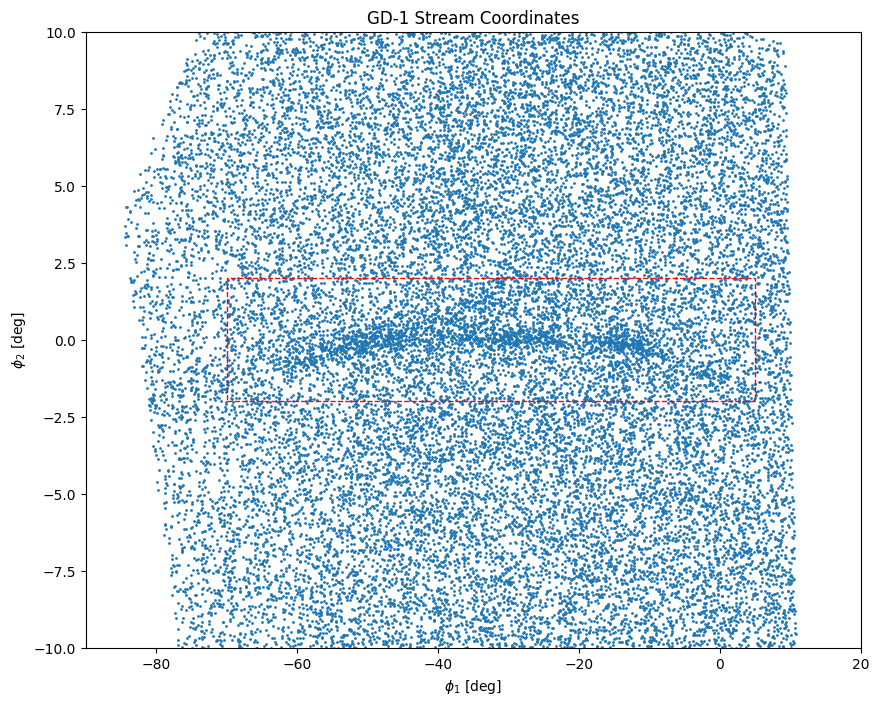

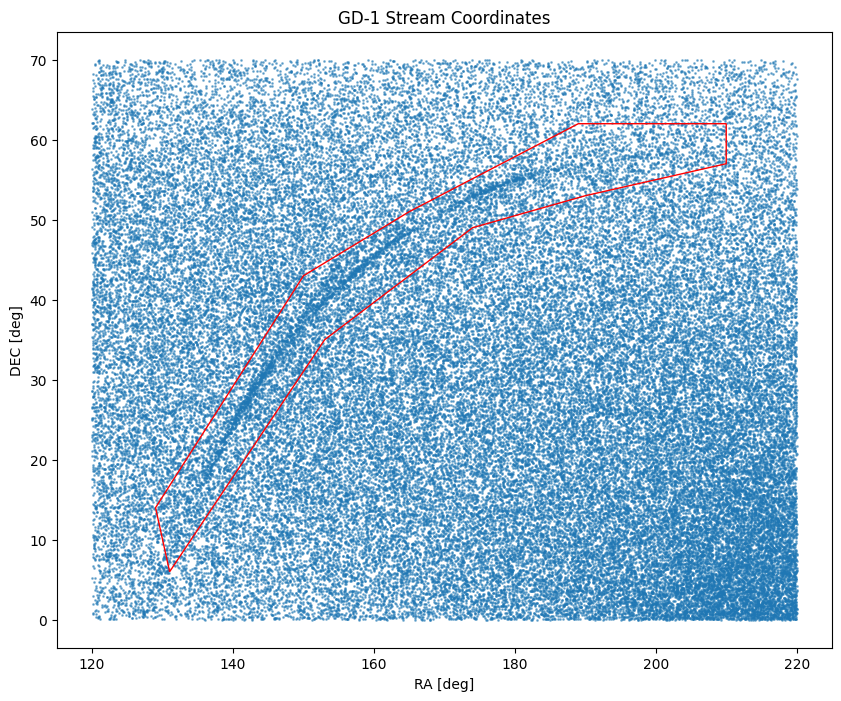

In [ ]:
GD1_canditate = cluster[cluster["pm_phi1"].between(-14, -8) & cluster["pm_phi2"].between(-4.5, -2.2)]

print ("\nNo. of Stars in the GD1_canditate Cluster :", len(GD1_canditate))




plt.figure(figsize=(10,8))

plt.scatter(
    GD1_canditate["phi1"],
    GD1_canditate["phi2"],
    s=1
)

plt.gca().add_patch(Rectangle(
        (-70, -2),
        75,
        4,
        fill=False,
        edgecolor='red',
        linestyle='--'
    )
)

plt.xlabel(r'$\phi_1$ [deg]')
plt.ylabel(r'$\phi_2$ [deg]')

plt.xlim(-90,20)
plt.ylim(-10,10)


plt.title("GD-1 Stream Coordinates")

plt.show()



plt.figure(figsize=(10,8))

plt.scatter(
     GD1_canditate["ra"],
     GD1_canditate["dec"],
     s=1,
     alpha=0.5
)

vertices = [[131,6],
            [129,14],
            [150,43],
            [165,51],
            [189,62],
            [210,62],
            [210,57],
            [190,53],
            [174,49],
            [153,35]]


plt.gca().add_patch(Polygon(
        vertices,
        fill=False,
        edgecolor='red'
    )
)


plt.xlabel(r'RA [deg]')
plt.ylabel(r'DEC [deg]')


plt.title("GD-1 Stream Coordinates")
plt.show()

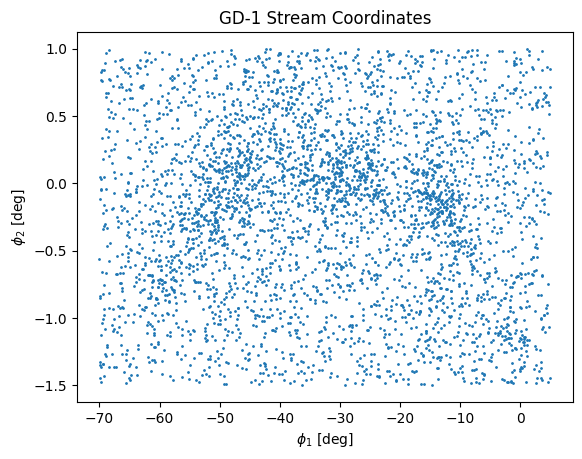


No. of Stars in the Selected Cluster : 3899


In [ ]:
GD1= GD1_canditate[GD1_canditate["phi1"].between(-70, 5) & GD1_canditate["phi2"].between(-1.5,1)]


plt.scatter(
    GD1["phi1"],
    GD1["phi2"],
    s=1
)


plt.xlabel(r'$\phi_1$ [deg]')
plt.ylabel(r'$\phi_2$ [deg]')



plt.title("GD-1 Stream Coordinates")

plt.show()

print ("\nNo. of Stars in the Selected Cluster :", len(GD1))


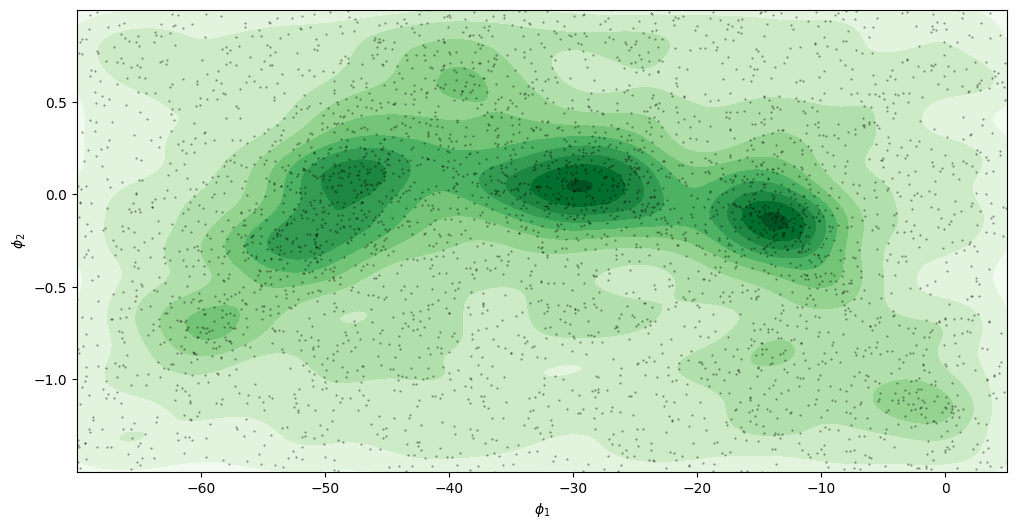

In [ ]:

x = GD1["phi1"].values
y = GD1["phi2"].values

kde = gaussian_kde(np.vstack([x, y]), bw_method=0.15)




xi = np.linspace(x.min(), x.max(), 300)
yi = np.linspace(y.min(), y.max(), 300)




X, Y = np.meshgrid(xi, yi)

Z = kde(np.vstack([X.ravel(), Y.ravel()]))

Z = Z.reshape(X.shape)







plt.figure(figsize=(12,6))

plt.contourf(
    X,
    Y,
    Z,
    levels=12,
    cmap="Greens"
)

plt.scatter(x, y, s=0.2, c="k", alpha=0.5)

plt.xlabel(r"$\phi_1$")
plt.ylabel(r"$\phi_2$")

plt.show()





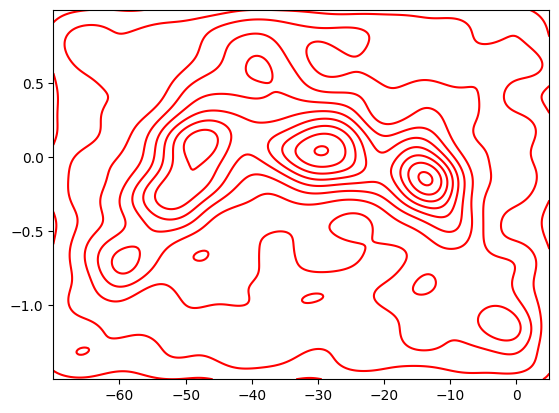

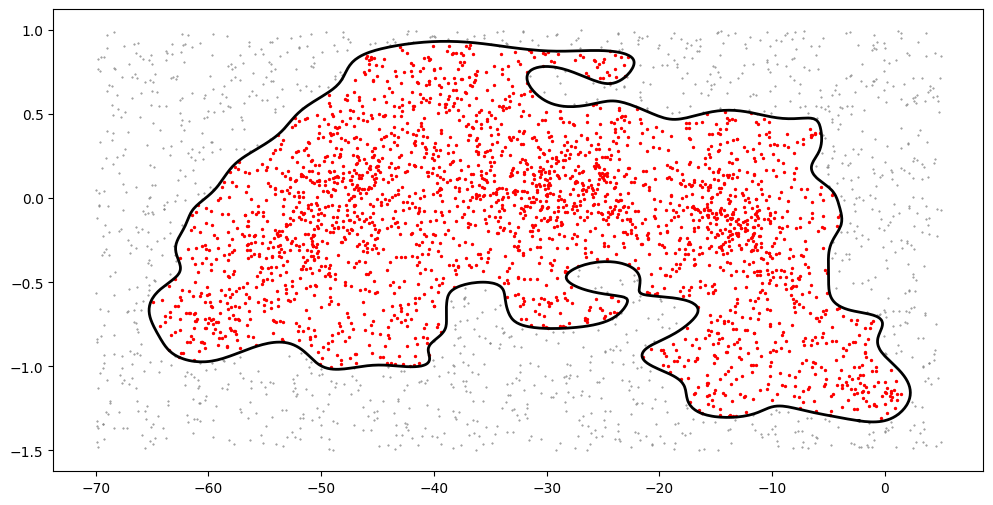

In [ ]:
cs = plt.contour(
    X,
    Y,
    Z,
    levels=12,
    colors='red'
)



level = 3
vertices = cs.allsegs[level][0]


from matplotlib.path import Path

path = Path(vertices)

mask = path.contains_points(GD1[["phi1", "phi2"]].values)

selected = GD1[mask]

plt.figure(figsize=(12,6))

plt.scatter(GD1["phi1"], GD1["phi2"], s=0.2, color="gray")

plt.scatter(
    selected["phi1"],
    selected["phi2"],
    s=2,
    color="red"
)

plt.plot(vertices[:,0], vertices[:,1], "k", lw=2)

plt.show()

GD1=selected

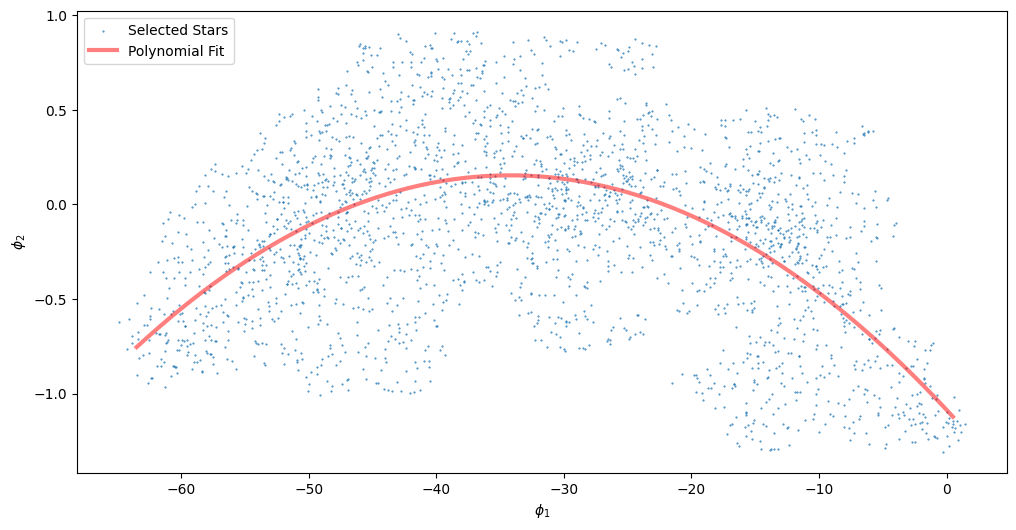

In [ ]:
bins = np.arange(-70, 10, 1)

centres = []
phi2_med = []

for i in range(len(bins)-1):

    m = ((GD1.phi1 >= bins[i]) & (GD1.phi1 < bins[i+1]))

    if m.sum() > 5: # Ensuring there are enough points for bin

        centres.append((bins[i]+bins[i+1])/2)
        phi2_med.append(GD1.loc[m,"phi2"].median())


centres = np.array(centres)
phi2_med = np.array(phi2_med)




coef = np.polyfit( centres, phi2_med, 2)

poly = np.poly1d(coef)

xfit = np.linspace( centres.min(), centres.max(), 300)

yfit = poly(xfit)



plt.figure(figsize=(12,6))

plt.scatter(
    GD1.phi1,
    GD1.phi2,
    s=0.2,
    label="Selected Stars"
)


plt.plot(
    xfit,
    yfit,
    color="red",
    lw=3,
    alpha=0.5,
    label="Polynomial Fit"
)

plt.xlabel(r"$\phi_1$")
plt.ylabel(r"$\phi_2$")
plt.legend(loc="upper left")

plt.show()

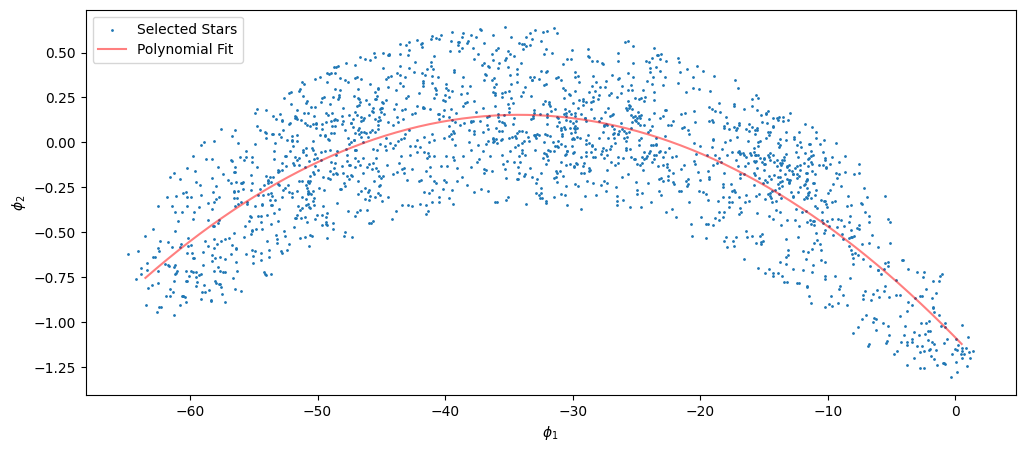

In [ ]:
width = 0.5

predicted = poly(GD1["phi1"])

mask = np.abs( GD1["phi2"] - predicted) < width

stream = GD1[mask]



plt.figure(figsize=(12,5))

plt.scatter(
    stream.phi1,
    stream.phi2,
    s=1,
    label="Selected Stars"
)


plt.plot(
    xfit,
    yfit,
    color="red",
    alpha=0.5,
    label="Polynomial Fit"
)


plt.xlabel(r"$\phi_1$")
plt.ylabel(r"$\phi_2$")
plt.legend(loc="upper left")


plt.show()

---
## Density Profile

The number of stars is counted along the stream to create a one-dimensional density profile.

This profile can be used to look for changes in the stream density.

<br>
<br>
<br>
<br>
---

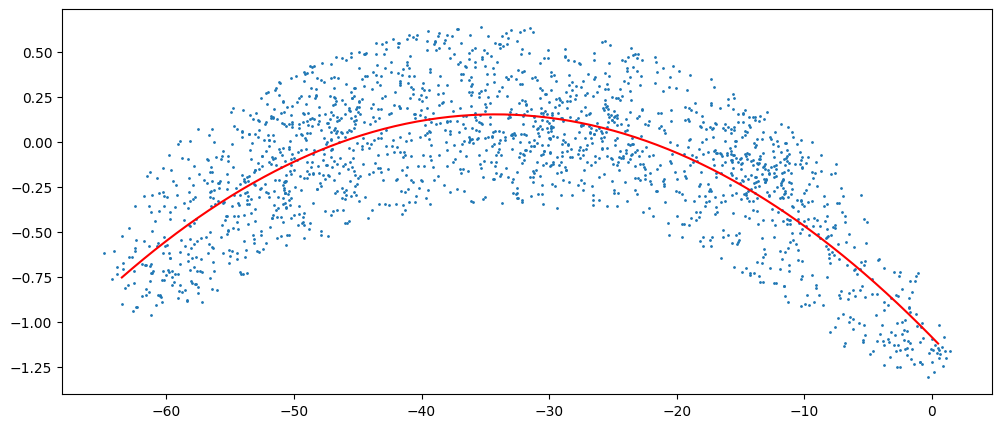

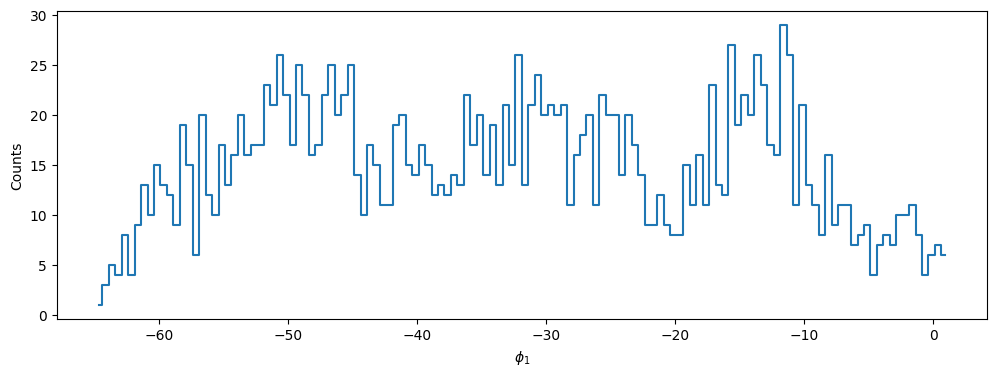

In [ ]:
bins = np.arange( stream.phi1.min(), stream.phi1.max(), 0.5)


counts, edges = np.histogram( stream.phi1, bins=bins)


centres = 0.5*(edges[:-1]+edges[1:])




plt.figure(figsize=(12,5))

plt.scatter(
    stream.phi1,
    stream.phi2,
    s=1
)

plt.plot(
    xfit,
    yfit,
    color="red"
)

plt.show()


plt.figure(figsize=(12,4))

plt.step(
    centres,
    counts,
    where="mid"
)

plt.xlabel(r"$\phi_1$")
plt.ylabel("Counts")

plt.show()

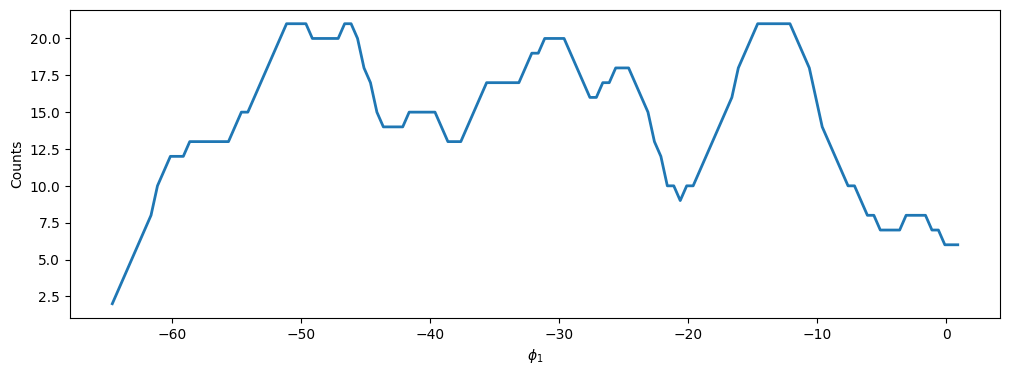

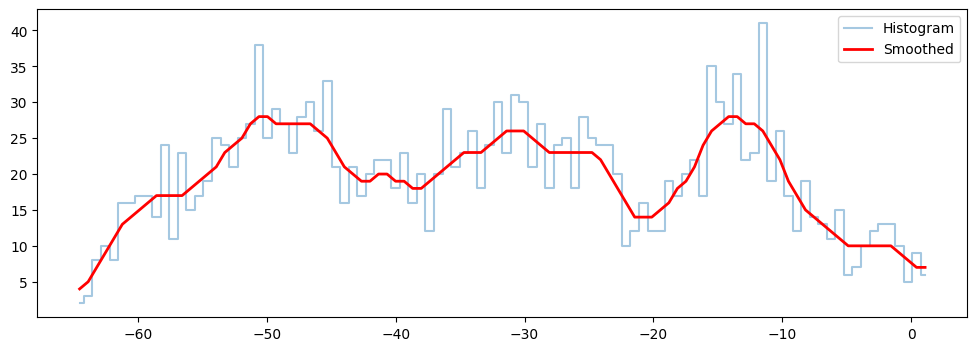

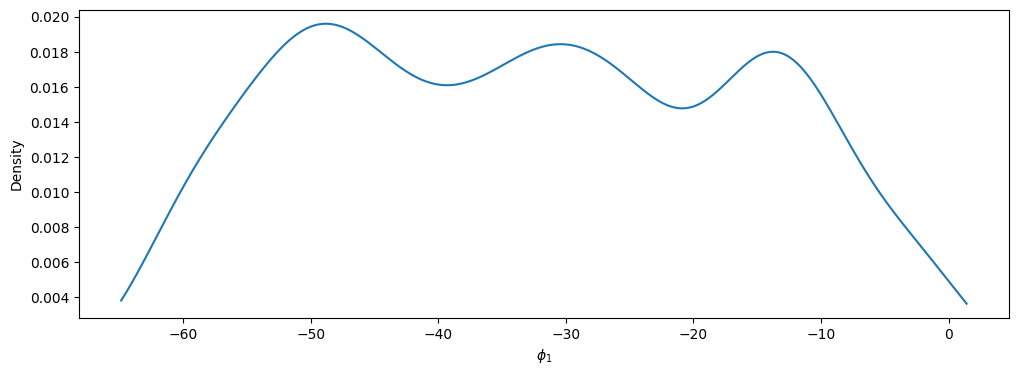

In [ ]:
from scipy.ndimage import gaussian_filter1d

bins = np.arange( stream.phi1.min(), stream.phi1.max(), 0.5)

counts, edges = np.histogram(stream["phi1"], bins)

centers = 0.5 * (edges[:-1] + edges[1:])

smooth = gaussian_filter1d(counts, sigma=2)

plt.figure(figsize=(12,4))
plt.plot(centers, smooth, lw=2)
plt.xlabel(r'$\phi_1$')
plt.ylabel("Counts")
plt.show()




counts, edges = np.histogram(stream["phi1"], bins=100)
centers = (edges[:-1] + edges[1:]) / 2

smooth = gaussian_filter1d(counts, sigma=2)

plt.figure(figsize=(12,4))
plt.step(centers, counts, where="mid", alpha=0.4, label="Histogram")
plt.plot(centers, smooth, 'r', lw=2, label="Smoothed")
plt.legend()
plt.show()




from scipy.stats import gaussian_kde

phi1 = stream["phi1"].values

kde = gaussian_kde(phi1)

x = np.linspace(phi1.min(), phi1.max(), 500)

plt.figure(figsize=(12,4))
plt.plot(x, kde(x))
plt.xlabel(r'$\phi_1$')
plt.ylabel("Density")
plt.show()

---
# Part 6: Results and Interpretation

The filtering steps successfully selected a clear group of likely GD-1 stream stars.

The fitted curve follows the shape of the stream, making it easier to select the final stream stars. The density profile shows how the number of stars changes along different parts of the stream.

These results provide a good starting point for studying the GD-1 stream in more detail.

<br>
<br>

---
# Part 7: Conclusion and Future Works

In this notebook, Gaia DR3 data was used to identify likely GD-1 stream stars.

The data was filtered in several steps before fitting the stream and creating a density profile.

Future work will focus on studying changes in the stream and comparing the results with simulations.

<br>
<br>

---
# Part 8: References

- Gaia Data Release 3
- Gaia Archive
- Astropy
- Astroquery
- gala
- Koposov et al. (2010)
- Price-Whelan & Bonaca (2018)

<br>
<br>

---